In [ ]:
%matplotlib notebook
%matplotlib inline

#All of the imports
import sionna.rt
import matplotlib.pyplot as plt
import numpy as np
import math
import drjit as dr
import mitsuba as mi
from typing import Tuple, List
import random 

from sionna.rt import load_scene, PlanarArray, Transmitter, Receiver, Camera,\
                      PathSolver, RadioMapSolver, subcarrier_frequencies

from tabulate import tabulate

#Where all the constants RF harvesting functions, and custom display functions are stored
import radio_functions

#Animation
import matplotlib.animation as animation

import matplotlib as mpl

using_preview = True

In [2]:
min_distance_between_points = 0
def distance_between(a, b):
    return math.sqrt(math.pow(b[1] - a[1], 2) + math.pow(b[2]-a[2], 2))

#returns true if the position isn't close to o
def check_position_valid(pos, positions_array):
    for other_pos in positions_array:
        if(distance_between(pos, other_pos) < min_distance_between_points):
            return False
    
    return True

In [ ]:
current_scene = load_scene("3D_detailed_map_tiles/3D_Earth_blend.xml")
current_scene.preview();

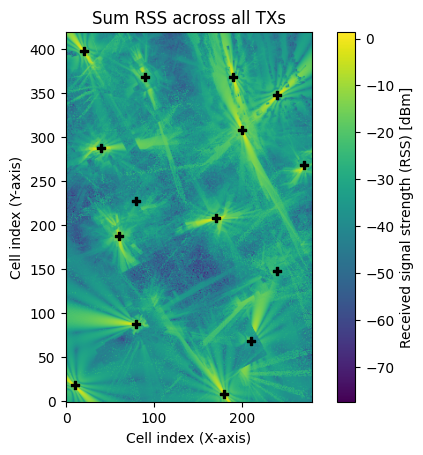

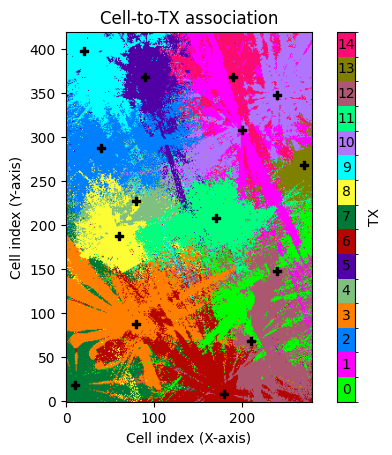

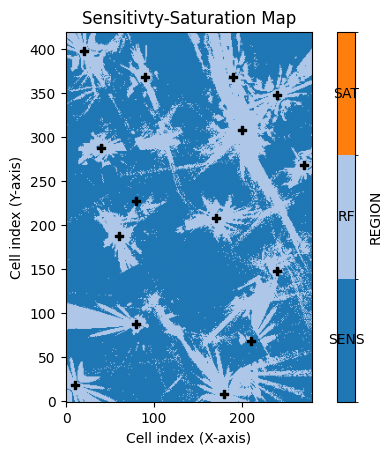

| Type   |   Recieved Power (dbm) |   DC energy (dbm) | time (s)   |
|--------+------------------------+-------------------+------------|
| Mean   |               -34.0535 |         -140      |            |
| Q1     |               -39.197  |         -140      |            |
| Median |               -33.6822 |         -140      |            |
| Q3     |               -28.5614 |          -40.1847 |            |


| Not enough RF   | Charging   | Saturation   |
|-----------------+------------+--------------|
| 70.569%         | 29.402%    | 0.029%       |


c:\Users\wonde\Documents\Extra_School_files\NSERC Research\UBC_tests\radio_functions.py:625: RuntimeWarning: overflow encountered in exp
  psig /= 1 + np.exp(-a*input_power + b)


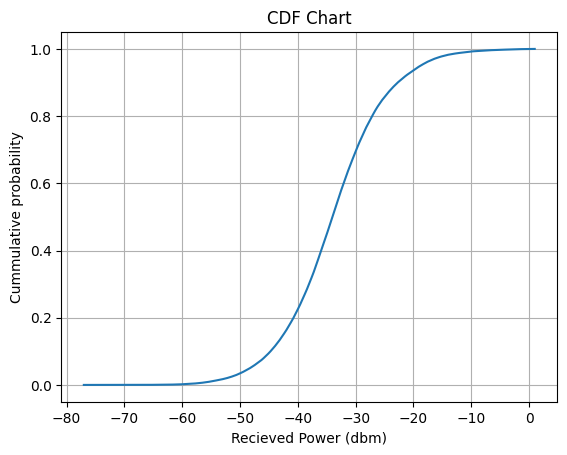

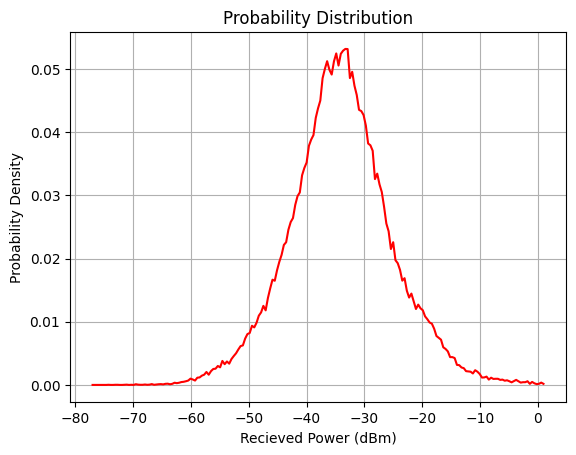

In [4]:
current_scene.frequency = 1.00001e9
num_cols = 8
current_scene.tx_array = PlanarArray(num_rows=1,
                             num_cols=num_cols, 
                             vertical_spacing=0.5,
                             horizontal_spacing=0.5,
                             pattern="iso",
                             polarization="V")

transmitters = []
positions_array = []

positions_array = [
    [500, -300, 30],
    [300, 500, 35],
    [-500, 400, 29],
    [-300, -600, 27],
    [-300, 100, 27],
    [-250, 800, 35],
    [200, -1000, 27],

    [-650, -950, 30],
    [-400, -100, 27],
    [-600, 950, 29],
    [500, 700, 35],
    [150, 0, 27],
    [350, -700, 27],
    [650, 300, 27],    # Adjusted further down toward center
    [250, 800, 27]
]

for i,_position in enumerate(positions_array):
    transmitters.append(Transmitter(name=f"tx{i}", position=_position, display_radius=10, power_dbm=54))
    transmitters[-1].orientation = (random.random()*360, 0, 0)
    current_scene.add(transmitters[-1])

num_transmitters = len(transmitters)
    
    
rm_solver = RadioMapSolver()
rm = rm_solver(current_scene,
               max_depth=30,           # Maximum number of ray scene interactions
               samples_per_tx=10**7 , # If you increase: less noise, but more memory required
               cell_size=(5, 5),      # Resolution of the radio map
               center=[0, 10, 1],      # Center of the radio map
               size=[1400, 2100],       # Total size of the radio map
               orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical



radio_functions.show_sum(rm, metric="rss")
radio_functions.show_association_more_colours(rm)
radio_functions.show_DC_regions(rm, metric="rss")

cdf_values = radio_functions.sum_cdf(rm, metric="rss");
metrics = radio_functions.calculate_metrics_from_cdf(cdf_values)
metrics.print_related_values()
metrics.display_cdf_and_pdf(cdf_values[2])
current_scene.preview(radio_map=rm);

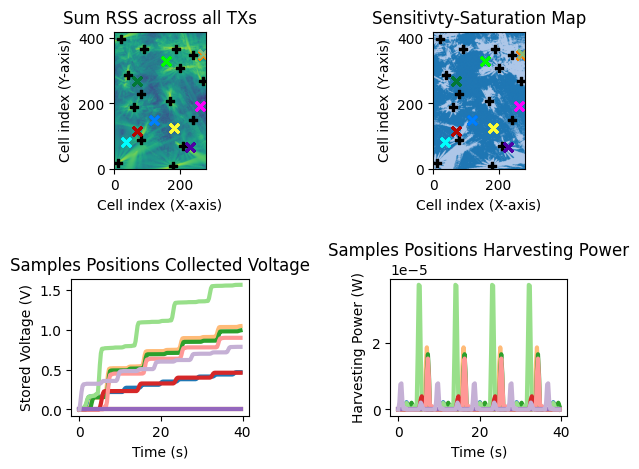

In [5]:
#Time simulation
#Samples 10 random positions and generates time-energy charts based on their charging

simulation_time = 40 #Total time of simulation in seconds
delta_time = 0.25 #Time between steps (in seconds)
rotation_speed = 10 #Speed of rotation (in deg/s)

num_sample_positions = 10
x_size = 280
y_size = 420


#Generate sampling positions
sample_cell_positions = []
stored_voltage_array = [] 
stored_power_array = []
for i in range(num_sample_positions):
    sample_cell_positions.append([random.randrange(0, 280), random.randrange(0, 420)])
    stored_voltage_array.append([0])
    stored_power_array.append([0])

#Plotting reciever positions
for i in range(num_sample_positions):
    position = mi.Point3f([sample_cell_positions[i][0], sample_cell_positions[i][1], 1])
    position *= 5
    position -= mi.Point3f([700, 1050, 0]) #Center at middle of array
    position += mi.Point3f([0, 10, 0]) #Add offset of radio_map

    current_scene.add(Receiver(name=f"rx_{i}", position = position))


rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**7 , # If you increase: less noise, but more memory required
        cell_size=(5, 5),      # Resolution of the radio map
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical


Artists = []
fig, [[ax, ax2], [ax3, ax4]] = plt.subplots(2, 2)
fig.subplots_adjust(0.125, 0.1,0.9, 0.9, 0.8, 0.8)
radio_functions.sum_animation_setup(rm, metric="rss", show_rx=True, fig=fig, ax = ax)
radio_functions.regions_animation_setup(rm, metric="rss", show_rx=True, fig=fig, ax = ax2)
ax3.set_ylabel("Stored Voltage (V)")
ax3.set_xlabel("Time (s)")
ax3.set_title("Samples Positions Collected Voltage")

ax4.set_ylabel("Harvesting Power (W)")
ax4.set_xlabel("Time (s)")
ax4.set_title("Samples Positions Harvesting Power")


x_axis = [0]

for time_step in range(int(simulation_time/delta_time)):
    
    #Solve radio map
    rm = rm_solver(current_scene,
        max_depth=30,           # Maximum number of ray scene interactions
        samples_per_tx=10**7 , # If you increase: less noise, but more memory required
        cell_size=(5, 5),      # Resolution of the radio map
        center=[0, 10, 1],      # Center of the radio map
        size=[1400, 2100],       # Total size of the radio map
        orientation=[0, 0, 0]) # Orientation of the radio map, e.g., could be also vertical

    sum_radio_map = radio_functions.sum_radio_map(rm, metric="rss")

    image = radio_functions.sum_animation(rm, metric="rss", axis=ax)
    image2 = radio_functions.regions_animation(rm, metric="rss", axis=ax2)
    lines = []

    for i in range(num_sample_positions):
        line = ax3.plot(x_axis, stored_voltage_array[i], color=mpl.colormaps['tab20'].colors[i], linewidth=3.0) 
        lines += line
        line = ax4.plot(x_axis, stored_power_array[i], color=mpl.colormaps['tab20'].colors[i], linewidth=3.0)
        lines += line

    lines.append(image)
    lines.append(image2)
    Artists.append(lines)
    x_axis.append(time_step * delta_time)

    for i in range(num_sample_positions):
        #For some reason the radio map has x and y reversed
        recieved_signal_strength = sum_radio_map[sample_cell_positions[i][1]][sample_cell_positions[i][0]]
        recieved_DC_power = radio_functions.DC_power_recieved(recieved_signal_strength)
        
        #Creates a new data point for the stored voltage at this time
        new_voltage = radio_functions.calculate_final_voltage(recieved_DC_power, delta_time, stored_voltage_array[i][-1])
        stored_voltage_array[i].append(new_voltage)
        stored_power_array[i].append(recieved_DC_power)

    
    #rotate transmitters 
    deg_rotation = delta_time * rotation_speed * (2 * math.pi/180)
    for i in range(num_transmitters):
        transmitters[i].orientation[0] += deg_rotation


anim = animation.ArtistAnimation(fig=fig, artists=Artists, interval=80)
anim.save("Test3_Animations/Array_ROTATING_Antennas.gif", writer="pillow")
plt.show()

